In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  accuracy_score,f1_score,confusion_matrix,precision_score,recall_score,precision_recall_curve
data= pd.read_csv("dataset.csv")
data.mental_health_risk.value_counts()




mental_health_risk
1    11823
0     9357
2     3820
Name: count, dtype: int64

In [3]:
#binary classification
#extract the data
bdata=[]
for i in range(len(data)):
    if data.mental_health_risk[i]!=2:
        bdata.append(data.loc[i])
bdata=pd.DataFrame(bdata)  
bdata.index=range(len(bdata))  
print(bdata.mental_health_risk.value_counts())
bdata.head()  

mental_health_risk
1    11823
0     9357
Name: count, dtype: int64


,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0
3,58,Male,Married,Master,Employed,9.4,12.8,5.9,7,7,...,6,3,1,3,0,0,1,0,0,0
4,22,Other,Married,PhD,Employed,6.9,11.6,6.4,10,10,...,4,5,7,7,0,0,0,0,1,0


In [4]:
#split the dataset into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(bdata.drop("mental_health_risk",axis=1),bdata.mental_health_risk,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

# align columns (important)
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)


(16944, 24) (4236, 24) (16944,) (4236,)


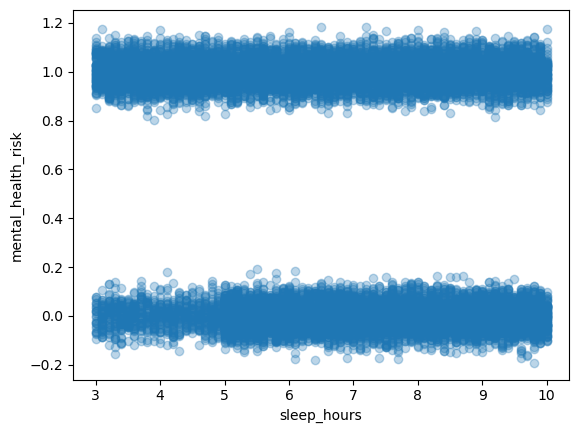

In [5]:
import numpy as np

y_jitter = bdata['mental_health_risk'] + np.random.normal(0, 0.05, size=len(bdata))

plt.scatter(bdata['sleep_hours'], y_jitter, alpha=0.3)
plt.xlabel('sleep_hours')
plt.ylabel('mental_health_risk')
plt.show()

In [6]:
model= LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)
y_pred= model.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))

accuracy 0.7974504249291785
f1 score 0.8228004956629492
confusion matrix [[1386  481]
 [ 377 1992]]
precision 0.8054993934492519
recall 0.8408611228366399


In [7]:
from sklearn.tree import DecisionTreeClassifier
tree= DecisionTreeClassifier(max_depth=10, random_state=42)
tree.fit(x_train, y_train)
y_pred_tree= tree.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred_tree))
print("f1 score",f1_score(y_test,y_pred_tree))
print("confusion matrix",confusion_matrix(y_test,y_pred_tree))
print("precision",precision_score(y_test,y_pred_tree))
print("recall",recall_score(y_test,y_pred_tree))


accuracy 0.9990557129367328
f1 score 0.9991554054054054
confusion matrix [[1866    1]
 [   3 2366]]
precision 0.9995775242923531
recall 0.9987336428872943


In [8]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=25)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred_rf))
print("f1 score",f1_score(y_test,y_pred_rf))
print("confusion matrix",confusion_matrix(y_test,y_pred_rf))
print("precision",precision_score(y_test,y_pred_rf))
print("recall",recall_score(y_test,y_pred_rf))

accuracy 0.9957507082152974
f1 score 0.996196111580727
confusion matrix [[1861    6]
 [  12 2357]]
precision 0.9974608548455354
recall 0.9949345715491769


In [9]:

from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("accuracy", accuracy_score(y_test, y_pred))
print("f1 score", f1_score(y_test, y_pred))
print("confusion matrix", confusion_matrix(y_test, y_pred))
print("precision", precision_score(y_test, y_pred))
print("recall", recall_score(y_test, y_pred))


accuracy 1.0
f1 score 1.0
confusion matrix [[1867    0]
 [   0 2369]]
precision 1.0
recall 1.0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [11]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.5).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))


Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 814us/step - accuracy: 0.7051 - loss: 0.5528 - val_accuracy: 0.8029 - val_loss: 0.4188
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 0.8161 - loss: 0.3881 - val_accuracy: 0.8185 - val_loss: 0.3831
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - accuracy: 0.8373 - loss: 0.3484 - val_accuracy: 0.8312 - val_loss: 0.3551
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - accuracy: 0.8537 - loss: 0.3182 - val_accuracy: 0.8448 - val_loss: 0.3363
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - accuracy: 0.8655 - loss: 0.2973 - val_accuracy: 0.8504 - val_loss: 0.3262
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step - accuracy: 0.8718 - loss: 0.2822 - val_accuracy: 0.8531 - val_loss: 0.3195
Epoch 7/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - accuracy: 0.8779 - loss: 0.2707 - val_accuracy: 0.8554 - val_loss: 0.3156
Epoch 8/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - accuracy: 0.8839 - loss: 0.2605 - val_accurac

In [18]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.8).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))


Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7752 - loss: 0.4580 - recall: 0.8444 - val_accuracy: 0.8262 - val_loss: 0.3669 - val_recall: 0.9498
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8431 - loss: 0.3301 - recall: 0.8886 - val_accuracy: 0.8374 - val_loss: 0.3561 - val_recall: 0.9439
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8679 - loss: 0.2794 - recall: 0.8930 - val_accuracy: 0.8649 - val_loss: 0.3274 - val_recall: 0.9178
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8924 - loss: 0.2355 - recall: 0.9050 - val_accuracy: 0.8678 - val_loss: 0.3377 - val_recall: 0.9519
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9191 - loss: 0.1818 - recall: 0.9339 - val_accuracy: 0.8640 - val_loss: 0.3754 - val_recall: 0.9610
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9388 - loss: 0.1443 - recall: 0.9534 - val_accuracy: 0.8864 - val_loss: 0.3353 - val_recall: 0.9477
Epoch 7/20
424

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.8).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7673 - loss: 0.4618 - recall: 0.8358 - val_accuracy: 0.8280 - val_loss: 0.3653 - val_recall: 0.9439
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8449 - loss: 0.3321 - recall: 0.8876 - val_accuracy: 0.8410 - val_loss: 0.3467 - val_recall: 0.9391
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8617 - loss: 0.2820 - recall: 0.8924 - val_accuracy: 0.8460 - val_loss: 0.3454 - val_recall: 0.9269
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8849 - loss: 0.2435 - recall: 0.9025 - val_accuracy: 0.8625 - val_loss: 0.3258 - val_recall: 0.9295
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9081 - loss: 0.1990 - recall: 0.9266 - val_accuracy: 0.8560 - val_loss: 0.3815 - val_recall: 0.9375
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9299 - loss: 0.1606 - recall: 0.9452 - val_accuracy: 0.8646 - val_loss: 0.4072 - val_recall: 0.9519
Epoch 7/20
424/

In [62]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.8).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7697 - loss: 0.4558 - recall: 0.8370 - val_accuracy: 0.8292 - val_loss: 0.3628 - val_recall: 0.9445
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8464 - loss: 0.3263 - recall: 0.8871 - val_accuracy: 0.8460 - val_loss: 0.3356 - val_recall: 0.9285
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8726 - loss: 0.2697 - recall: 0.8966 - val_accuracy: 0.8663 - val_loss: 0.3219 - val_recall: 0.9354
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9033 - loss: 0.2174 - recall: 0.9147 - val_accuracy: 0.8772 - val_loss: 0.3049 - val_recall: 0.9370
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9283 - loss: 0.1692 - recall: 0.9367 - val_accuracy: 0.8811 - val_loss: 0.3298 - val_recall: 0.9418
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9477 - loss: 0.1301 - recall: 0.9534 - val_accuracy: 0.8849 - val_loss: 0.3221 - val_recall: 0.9482
Epoch 7/20
424/

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.8).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7710 - loss: 0.4572 - recall: 0.8296 - val_accuracy: 0.8280 - val_loss: 0.3620 - val_recall: 0.9407
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8450 - loss: 0.3293 - recall: 0.8851 - val_accuracy: 0.8457 - val_loss: 0.3345 - val_recall: 0.9407
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8717 - loss: 0.2765 - recall: 0.8956 - val_accuracy: 0.8681 - val_loss: 0.3070 - val_recall: 0.9429
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9030 - loss: 0.2212 - recall: 0.9176 - val_accuracy: 0.8852 - val_loss: 0.2851 - val_recall: 0.9461
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9246 - loss: 0.1707 - recall: 0.9350 - val_accuracy: 0.8861 - val_loss: 0.3198 - val_recall: 0.9482
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9457 - loss: 0.1316 - recall: 0.9548 - val_accuracy: 0.8899 - val_loss: 0.3261 - val_recall: 0.9487
Epoch 7/20
424/

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.7).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7677 - loss: 0.4578 - recall: 0.8324 - val_accuracy: 0.8292 - val_loss: 0.3619 - val_recall: 0.9429
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8468 - loss: 0.3298 - recall: 0.8855 - val_accuracy: 0.8427 - val_loss: 0.3395 - val_recall: 0.9386
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8696 - loss: 0.2779 - recall: 0.8965 - val_accuracy: 0.8563 - val_loss: 0.3185 - val_recall: 0.9381
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8941 - loss: 0.2287 - recall: 0.9106 - val_accuracy: 0.8690 - val_loss: 0.3154 - val_recall: 0.9258
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9194 - loss: 0.1810 - recall: 0.9320 - val_accuracy: 0.8711 - val_loss: 0.3453 - val_recall: 0.9386
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9397 - loss: 0.1392 - recall: 0.9503 - val_accuracy: 0.8722 - val_loss: 0.3707 - val_recall: 0.9493
Epoch 7/20
424/

In [64]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.5).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7679 - loss: 0.4591 - recall: 0.8429 - val_accuracy: 0.8283 - val_loss: 0.3590 - val_recall: 0.9418
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8470 - loss: 0.3261 - recall: 0.8837 - val_accuracy: 0.8463 - val_loss: 0.3319 - val_recall: 0.9397
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8762 - loss: 0.2642 - recall: 0.8947 - val_accuracy: 0.8719 - val_loss: 0.2984 - val_recall: 0.9263
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9083 - loss: 0.2093 - recall: 0.9173 - val_accuracy: 0.8814 - val_loss: 0.2916 - val_recall: 0.9434
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9337 - loss: 0.1600 - recall: 0.9440 - val_accuracy: 0.8834 - val_loss: 0.3116 - val_recall: 0.9365
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9463 - loss: 0.1321 - recall: 0.9527 - val_accuracy: 0.8867 - val_loss: 0.3429 - val_recall: 0.9541
Epoch 7/20
424/

In [65]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.3).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7694 - loss: 0.4575 - recall: 0.8404 - val_accuracy: 0.8280 - val_loss: 0.3605 - val_recall: 0.9386
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8472 - loss: 0.3263 - recall: 0.8868 - val_accuracy: 0.8504 - val_loss: 0.3306 - val_recall: 0.9338
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8754 - loss: 0.2720 - recall: 0.9009 - val_accuracy: 0.8548 - val_loss: 0.3258 - val_recall: 0.9423
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9033 - loss: 0.2238 - recall: 0.9193 - val_accuracy: 0.8702 - val_loss: 0.3028 - val_recall: 0.9386
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9251 - loss: 0.1739 - recall: 0.9379 - val_accuracy: 0.8832 - val_loss: 0.3005 - val_recall: 0.9375
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9441 - loss: 0.1366 - recall: 0.9529 - val_accuracy: 0.8849 - val_loss: 0.3295 - val_recall: 0.9237
Epoch 7/20
424/

In [70]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.45).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7721 - loss: 0.4586 - recall: 0.8404 - val_accuracy: 0.8265 - val_loss: 0.3682 - val_recall: 0.9418
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8439 - loss: 0.3348 - recall: 0.8844 - val_accuracy: 0.8395 - val_loss: 0.3385 - val_recall: 0.9359
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8686 - loss: 0.2831 - recall: 0.8974 - val_accuracy: 0.8557 - val_loss: 0.3273 - val_recall: 0.9397
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8942 - loss: 0.2336 - recall: 0.9103 - val_accuracy: 0.8734 - val_loss: 0.3125 - val_recall: 0.9466
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9181 - loss: 0.1856 - recall: 0.9319 - val_accuracy: 0.8864 - val_loss: 0.2996 - val_recall: 0.9386
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9386 - loss: 0.1402 - recall: 0.9468 - val_accuracy: 0.8920 - val_loss: 0.3083 - val_recall: 0.9413
Epoch 7/20
424/

In [73]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.4).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/20


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7704 - loss: 0.4575 - recall: 0.8439 - val_accuracy: 0.8289 - val_loss: 0.3581 - val_recall: 0.9258
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8455 - loss: 0.3289 - recall: 0.8848 - val_accuracy: 0.8489 - val_loss: 0.3299 - val_recall: 0.9322
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8715 - loss: 0.2770 - recall: 0.8976 - val_accuracy: 0.8663 - val_loss: 0.3151 - val_recall: 0.9311
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8969 - loss: 0.2285 - recall: 0.9089 - val_accuracy: 0.8775 - val_loss: 0.3016 - val_recall: 0.9237
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9235 - loss: 0.1817 - recall: 0.9334 - val_accuracy: 0.8834 - val_loss: 0.3167 - val_recall: 0.9434
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9455 - loss: 0.1375 - recall: 0.9521 - val_accuracy: 0.8885 - val_loss: 0.3196 - val_recall: 0.9226
Epoch 7/20
424/

In [80]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
model.fit(x_train_scaled, y_train, epochs=18, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.35).astype("int32")
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/18


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7697 - loss: 0.4570 - recall: 0.8484 - val_accuracy: 0.8309 - val_loss: 0.3605 - val_recall: 0.9402
Epoch 2/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8459 - loss: 0.3270 - recall: 0.8840 - val_accuracy: 0.8513 - val_loss: 0.3302 - val_recall: 0.9338
Epoch 3/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8787 - loss: 0.2663 - recall: 0.8989 - val_accuracy: 0.8660 - val_loss: 0.3105 - val_recall: 0.9359
Epoch 4/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9029 - loss: 0.2141 - recall: 0.9144 - val_accuracy: 0.8790 - val_loss: 0.3044 - val_recall: 0.9429
Epoch 5/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9307 - loss: 0.1636 - recall: 0.9421 - val_accuracy: 0.8885 - val_loss: 0.3088 - val_recall: 0.9450
Epoch 6/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9442 - loss: 0.1341 - recall: 0.9524 - val_accuracy: 0.8932 - val_loss: 0.3079 - val_recall: 0.9333
Epoch 7/18
424/

Epoch 1/18


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7734 - loss: 0.4534 - recall: 0.8429 - val_accuracy: 0.8339 - val_loss: 0.3534 - val_recall: 0.9370
Epoch 2/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8490 - loss: 0.3224 - recall: 0.8866 - val_accuracy: 0.8448 - val_loss: 0.3349 - val_recall: 0.9322
Epoch 3/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8734 - loss: 0.2705 - recall: 0.8975 - val_accuracy: 0.8575 - val_loss: 0.3308 - val_recall: 0.9439
Epoch 4/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9013 - loss: 0.2224 - recall: 0.9166 - val_accuracy: 0.8672 - val_loss: 0.3186 - val_recall: 0.9407
Epoch 5/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9217 - loss: 0.1797 - recall: 0.9330 - val_accuracy: 0.8719 - val_loss: 0.3276 - val_recall: 0.9423
Epoch 6/18
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9466 - loss: 0.1327 - recall: 0.9548 - val_accuracy: 0.8876 - val_loss: 0.3385 - val_recall: 0.9402
Epoch 7/18
424/

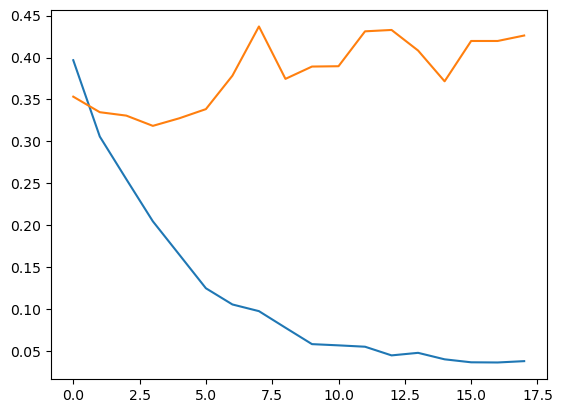

In [82]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
history=model.fit(x_train_scaled, y_train, epochs=18, batch_size=32, validation_split=0.2)
y_pred_nn = (model.predict(x_test_scaled) > 0.35).astype("int32")

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

Epoch 1/40


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7708 - loss: 0.4573 - recall: 0.8418 - val_accuracy: 0.8271 - val_loss: 0.3680 - val_recall: 0.9477
Epoch 2/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8474 - loss: 0.3310 - recall: 0.8854 - val_accuracy: 0.8457 - val_loss: 0.3357 - val_recall: 0.9349
Epoch 3/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8688 - loss: 0.2802 - recall: 0.8941 - val_accuracy: 0.8666 - val_loss: 0.3108 - val_recall: 0.9391
Epoch 4/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8990 - loss: 0.2273 - recall: 0.9132 - val_accuracy: 0.8784 - val_loss: 0.2874 - val_recall: 0.9274
Epoch 5/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9252 - loss: 0.1770 - recall: 0.9342 - val_accuracy: 0.8891 - val_loss: 0.2969 - val_recall: 0.9493
Epoch 6/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9448 - loss: 0.1378 - recall: 0.9511 - val_accuracy: 0.8973 - val_loss: 0.2946 - val_recall: 0.9466
Epoch 7/40
424/

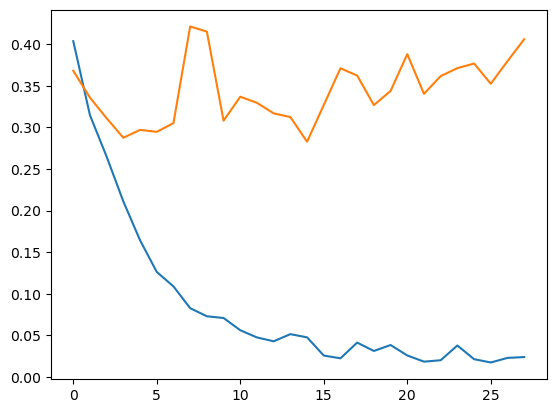

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=13, restore_best_weights=True)
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
history=model.fit(x_train_scaled, y_train, epochs=40, batch_size=32, validation_split=0.2,callbacks=[early_stop])
y_pred_nn = (model.predict(x_test_scaled) > 0.55).astype("int32")

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

Epoch 1/40


/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7694 - loss: 0.4600 - recall: 0.8451 - val_accuracy: 0.8280 - val_loss: 0.3595 - val_recall: 0.9365
Epoch 2/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8492 - loss: 0.3253 - recall: 0.8855 - val_accuracy: 0.8492 - val_loss: 0.3333 - val_recall: 0.9418
Epoch 3/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8747 - loss: 0.2733 - recall: 0.8994 - val_accuracy: 0.8625 - val_loss: 0.3178 - val_recall: 0.9354
Epoch 4/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8975 - loss: 0.2284 - recall: 0.9122 - val_accuracy: 0.8796 - val_loss: 0.3012 - val_recall: 0.9333
Epoch 5/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9207 - loss: 0.1805 - recall: 0.9318 - val_accuracy: 0.8846 - val_loss: 0.3003 - val_recall: 0.9327
Epoch 6/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9434 - loss: 0.1430 - recall: 0.9498 - val_accuracy: 0.8929 - val_loss: 0.3077 - val_recall: 0.9487
Epoch 7/40
424/

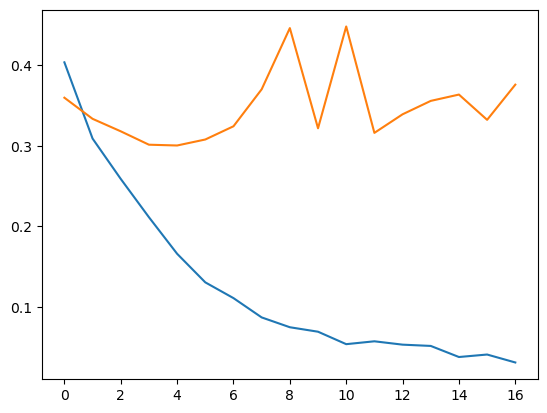

In [29]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=12, restore_best_weights=True)
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','recall'])
history=model.fit(x_train_scaled, y_train, epochs=40, batch_size=32, validation_split=0.2,callbacks=[early_stop])
y_pred_nn = (model.predict(x_test_scaled) > 0.45).astype("int32")

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
print("accuracy", accuracy_score(y_test, y_pred_nn))
print("f1 score", f1_score(y_test, y_pred_nn))
print("confusion matrix", confusion_matrix(y_test, y_pred_nn))
print("precision", precision_score(y_test, y_pred_nn))
print("recall", recall_score(y_test, y_pred_nn))

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step


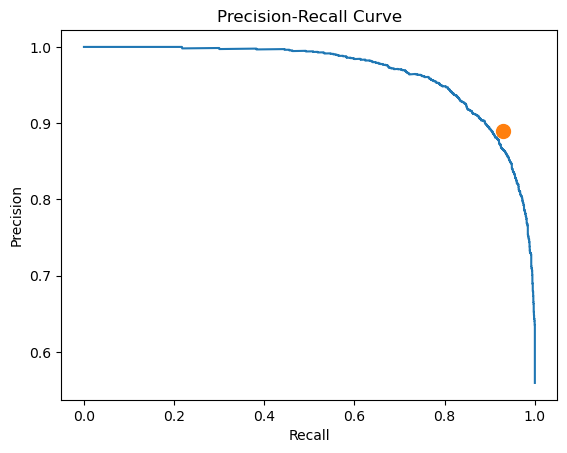

In [30]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_probs = model.predict(x_test_scaled).ravel()

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)


plt.plot(recall, precision)
plt.plot(0.93,0.89, marker='o', markersize=10, label='Point at Recall=0.4')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


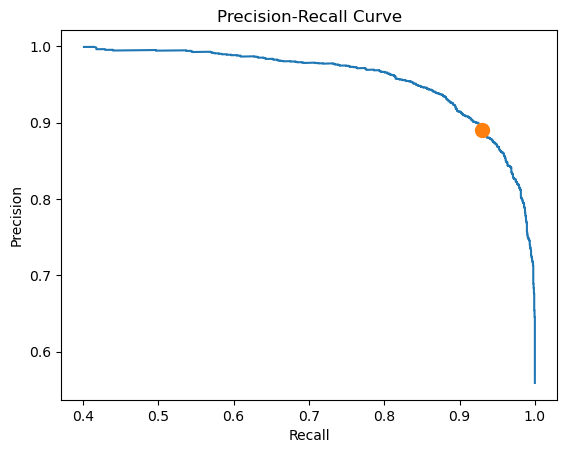

In [22]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_probs = model.predict(x_test_scaled).ravel()
precision_at_recall_0_4 = []
recall_at_recall_0_4 = []
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
for i in range(len(thresholds)):
    if recall[i]>0.4:
        precision_at_recall_0_4.append(precision[i])
        recall_at_recall_0_4.append(recall[i])

plt.plot(recall_at_recall_0_4, precision_at_recall_0_4, )
plt.plot(0.93,0.89, marker='o', markersize=10, label='Point at Recall=0.4')  

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()